**task 3 of Pandahat Adverserial Learning Path:** 

This task is centered around CNNs. A Convolutional Neural Network (CNN) is a deep learning model designed for spatially structured data, such as images, which are represented as grids of pixels. CNNs are widely used in computer vision tasks including image classification, object detection, and semantic segmentation. In this task, a CNN is applied to satellite NDVI images, and its performance is compared against the Support Vector Machine (SVM) from Task 2, as well as a pre-trained DeepLabV3+ model.

Unlike traditional fully connected neural networks, which connect every neuron to every input, CNNs preserve spatial relationships in the data. Fully connected networks become inefficient as input size increases and also ignore spatial structure, treating nearby pixels as unrelated even when they may belong to the same object (such as vegetation, water, or clouds).

CNNs solve this by using convolutional filters that slide across the image. These filters (kernels), often small such as 3×3, focus on local regions of the image at a time. Each filter learns to detect specific patterns like edges, textures, or small spatial structures. Because the same filter is applied across the entire image, the model can detect similar patterns regardless of their location.
Intuitively, this process can be thought of as a magnifying glass scanning across the image. At each position, the model focuses on a small region of pixels and extracts local patterns. As this operation moves across the image, the network gradually builds a representation of the overall spatial structure based on these local features.

DeepLabV3+ is particularly effective for vegetation detection because it uses atrous (dilated) convolutions and an Atrous Spatial Pyramid Pooling (ASPP) module to capture features at multiple spatial scales. Its encoder-decoder structure further helps refine object boundaries, which is important for accurately separating vegetation from surrounding land cover types.

# Convolutional Neural Network

Imports:

In [26]:
import numpy as np
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import seaborn as sns


class mapping/id mapping:

In [27]:
class_to_id = {
    "Water/Cloud": 0,
    "Bare Soil": 1,
    "Sparse Vegetation": 2,
    "Dense Vegetation": 3
}

Sample loader:

In [28]:
base_dir = os.path.join(os.getcwd(), "..")
labels_path = os.path.join(base_dir, "labels")
samples_path = os.path.join(base_dir, "samples")

sample_files = sorted(glob.glob(os.path.join(samples_path, "*.tiff")))
label_files = sorted(glob.glob(os.path.join(labels_path,  "*.tiff")))
print(f"Found {len(sample_files)} samples, {len(label_files)} labels")

Found 614 samples, 614 labels


Extracting patches and assigning classes:

In [29]:
PATCH_SIZE = 7
HALF = PATCH_SIZE // 2  
PATCHES_PER_IMAGE = 50   

patches = []  
for img_path, lbl_path in zip(sample_files, label_files):
    img = np.array(Image.open(img_path))   
    label = np.array(Image.open(lbl_path))    

    ndvi = (label / 255.0) * 2 - 1
    H, W = img.shape[:2]

    rows = np.random.randint(HALF, H - HALF, size=PATCHES_PER_IMAGE)
    cols = np.random.randint(HALF, W - HALF, size=PATCHES_PER_IMAGE)

    for r, c in zip(rows, cols):
        patch = img[r-HALF:r+HALF+1, c-HALF:c+HALF+1, :]  

        ndvi_val = ndvi[r, c]
        
        if ndvi_val < 0:   
            veg_class = "Water/Cloud"
        elif ndvi_val < 0.2: 
            veg_class = "Bare Soil"
        elif ndvi_val < 0.5: 
            veg_class = "Sparse Vegetation"
        else:                
            veg_class = "Dense Vegetation"

        patches.append((patch, class_to_id[veg_class]))

print(f"Total patches collected: {len(patches)}")

Total patches collected: 30700


PyTorch Dataset and test split:

In [30]:
class PatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch, label = self.patches[idx]
        x = torch.tensor(patch / 255.0, dtype=torch.float32).permute(2, 0, 1)
        y = torch.tensor(label, dtype=torch.long)
        return x, y


train_patches, test_patches = train_test_split(patches, test_size=0.2, random_state=42)

train_dataset = PatchDataset(train_patches)
test_dataset = PatchDataset(test_patches)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")


Train: 24560 | Test: 6140


CNN Model:

In [31]:
class VegetationCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(VegetationCNN, self).__init__()

        def conv_block(in_ch, out_ch, k):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=0),
                nn.ReLU(),
                nn.Dropout2d(p=0.1)
            )

        self.conv1 = conv_block(3,  20, 3)
        self.conv2 = conv_block(20, 20, 3)
        self.conv3 = conv_block(20, 20, 3)
        self.conv4 = nn.Sequential(nn.Conv2d(20, 100, kernel_size=1), nn.ReLU(), nn.Dropout2d(p=0.1))

        self.fc = nn.Linear(100, num_classes)

    def forward(self, x):
        x = self.conv1(x)   
        x = self.conv2(x)  
        x = self.conv3(x)   
        x = self.conv4(x)   
        x = x.view(x.size(0), -1)  
        x = self.fc(x)      
        return x

Training and validation (This takes some time):

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

model = VegetationCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([3.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_acc = correct / total
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    
    avg_val_loss = val_loss / len(test_loader)
    val_acc = val_correct / val_total
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")



Using device: cuda
Epoch 01/20 | Train Loss: 1.1337 | Train Acc: 0.4825 | Val Loss: 0.9644 | Val Acc: 0.5961
Epoch 02/20 | Train Loss: 0.9415 | Train Acc: 0.6193 | Val Loss: 0.8068 | Val Acc: 0.7112
Epoch 03/20 | Train Loss: 0.8093 | Train Acc: 0.7060 | Val Loss: 0.6912 | Val Acc: 0.7669
Epoch 04/20 | Train Loss: 0.7580 | Train Acc: 0.7214 | Val Loss: 0.6396 | Val Acc: 0.7865
Epoch 05/20 | Train Loss: 0.7230 | Train Acc: 0.7317 | Val Loss: 0.6190 | Val Acc: 0.7849
Epoch 06/20 | Train Loss: 0.6977 | Train Acc: 0.7414 | Val Loss: 0.6267 | Val Acc: 0.7876
Epoch 07/20 | Train Loss: 0.6782 | Train Acc: 0.7496 | Val Loss: 0.6265 | Val Acc: 0.7904
Epoch 08/20 | Train Loss: 0.6723 | Train Acc: 0.7518 | Val Loss: 0.5952 | Val Acc: 0.7989
Epoch 09/20 | Train Loss: 0.6552 | Train Acc: 0.7610 | Val Loss: 0.5844 | Val Acc: 0.7912
Epoch 10/20 | Train Loss: 0.6526 | Train Acc: 0.7614 | Val Loss: 0.6184 | Val Acc: 0.7873
Epoch 11/20 | Train Loss: 0.6412 | Train Acc: 0.7682 | Val Loss: 0.5971 | Val Ac

Evaluation:

In [33]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
))



Test Accuracy: 0.7948

Classification Report:
              precision    recall  f1-score   support

 Water/Cloud       0.46      0.74      0.57       315
   Bare Soil       0.75      0.68      0.71      1190
  Sparse Veg       0.83      0.77      0.80      2416
   Dense Veg       0.85      0.90      0.88      2219

    accuracy                           0.79      6140
   macro avg       0.72      0.77      0.74      6140
weighted avg       0.80      0.79      0.80      6140



Confusion Matrix Visualization:

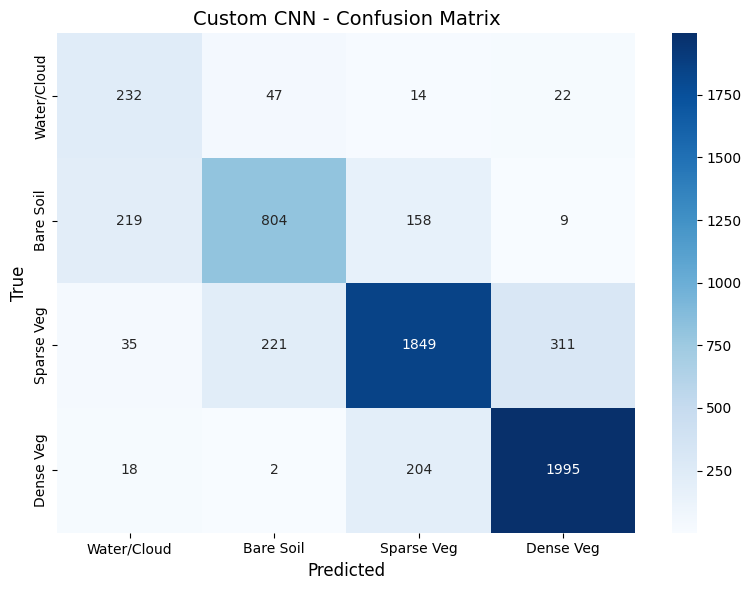


Confusion Matrix (raw values):
[[ 232   47   14   22]
 [ 219  804  158    9]
 [  35  221 1849  311]
 [  18    2  204 1995]]

 Confusion matrix saved to: cnn_confusion_matrix.png


In [34]:
class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']

cm = confusion_matrix(all_labels, all_preds)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Custom CNN - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

print("\nConfusion Matrix (raw values):")
print(cm)
print(f"\n Confusion matrix saved to: cnn_confusion_matrix.png")

Loss Curves Visualization:

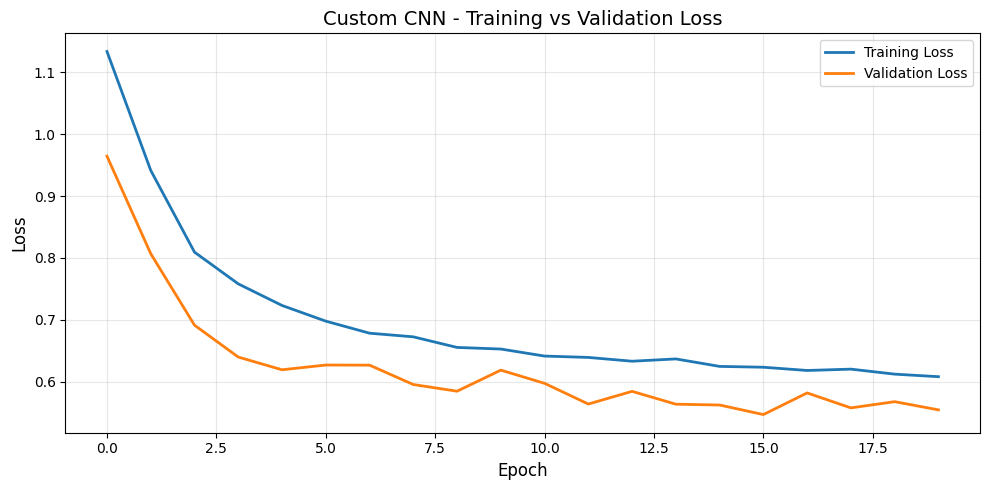

Length of train_losses: 20
Length of val_losses: 20
First 5 train losses: [1.1337345022087295, 0.9414673484861851, 0.8092826314580938, 0.7579611009762933, 0.7230232601674894]
Last 5 train losses: [0.623133727737392, 0.6178871909311662, 0.6200607816378275, 0.6119719860920062, 0.6078491848117361]
First 5 val losses: [0.9643779856463274, 0.8068051561713219, 0.6911610504612327, 0.6396053874244293, 0.6190000958740711]
Last 5 val losses: [0.5465882954498132, 0.5815815208479762, 0.5573863092189034, 0.5674428027123213, 0.5541928053523103]
Final Training Loss: 0.6078
Final Validation Loss: 0.5542

Training behavior looks good - losses are balanced

Loss curves saved to: cnn_loss_curves.png


In [35]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Custom CNN - Training vs Validation Loss', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_loss_curves.png', dpi=150)
plt.show()

print(f"Length of train_losses: {len(train_losses)}")
print(f"Length of val_losses: {len(val_losses)}")
print(f"First 5 train losses: {train_losses[:5]}")
print(f"Last 5 train losses: {train_losses[-5:]}")
print(f"First 5 val losses: {val_losses[:5]}")
print(f"Last 5 val losses: {val_losses[-5:]}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

# Check for overfitting/underfitting
if val_losses[-1] > train_losses[-1] * 1.2:
    print("\n Warning: Possible overfitting (validation loss > training loss by 20%)")
    print("   Consider: more regularization, dropout, or early stopping")
elif val_losses[-1] < train_losses[-1] * 0.8:
    print("\nWarning: Possible underfitting (validation loss < training loss)")
    print("   Consider: more epochs or a more complex model")
else:
    print("\nTraining behavior looks good - losses are balanced")

print(f"\nLoss curves saved to: cnn_loss_curves.png")

Prediction Visualizations:

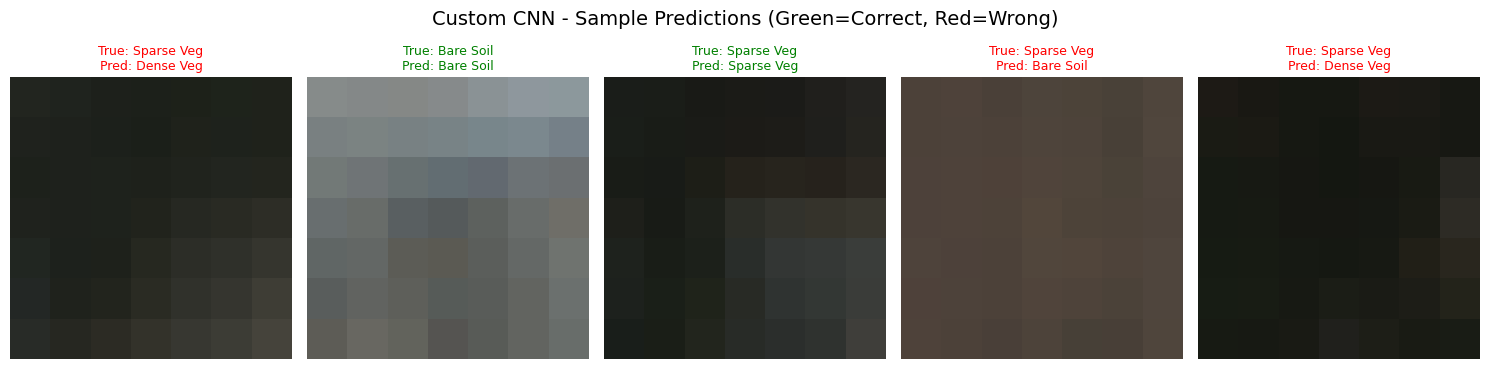


Prediction Details:
Sample 1: True=Sparse Veg, Pred=Dense Veg [ WRONG]
Sample 2: True=Bare Soil, Pred=Bare Soil [ CORRECT]
Sample 3: True=Sparse Veg, Pred=Sparse Veg [ CORRECT]
Sample 4: True=Sparse Veg, Pred=Bare Soil [ WRONG]
Sample 5: True=Sparse Veg, Pred=Dense Veg [ WRONG]

Accuracy on these 5 samples: 2/5 = 40%

Predictions visualization saved to: cnn_predictions.png


In [36]:
model.eval()
sample_images = []
sample_labels = []
sample_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)
        
        for i in range(min(5, len(X_batch))):
            sample_images.append(X_batch[i].cpu())
            sample_labels.append(y_batch[i].item())
            sample_preds.append(preds[i].item())
        
        if len(sample_images) >= 5:
            break

class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']


fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, (img, true_label, pred_label) in enumerate(zip(sample_images[:5], sample_labels[:5], sample_preds[:5])):
    img_display = img.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_display)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Custom CNN - Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_predictions.png', dpi=150)
plt.show()

print("\nPrediction Details:")
correct_count = 0
for i, (true_label, pred_label) in enumerate(zip(sample_labels[:5], sample_preds[:5])):
    status = " CORRECT" if true_label == pred_label else " WRONG"
    if true_label == pred_label:
        correct_count += 1
    print(f"Sample {i+1}: True={class_names[true_label]}, Pred={class_names[pred_label]} [{status}]")

print(f"\nAccuracy on these 5 samples: {correct_count}/5 = {correct_count/5*100:.0f}%")
print(f"\nPredictions visualization saved to: cnn_predictions.png")

# DeepLabV3+

Imports:

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation import deeplabv3_resnet50
from PIL import Image
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_to_id = {
    "Water/Cloud": 0,
    "Bare Soil": 1,
    "Sparse Vegetation": 2,
    "Dense Vegetation": 3
}

NUM_CLASSES = 4
IMG_SIZE = 256

Load file paths:

In [38]:
base_dir = os.path.join(os.getcwd(), "..")
labels_path = os.path.join(base_dir, "labels")
samples_path = os.path.join(base_dir, "samples")

sample_files = sorted(glob.glob(os.path.join(samples_path, "*.tiff")))
label_files = sorted(glob.glob(os.path.join(labels_path,  "*.tiff")))
print(f"Found {len(sample_files)} samples, {len(label_files)} labels")


Found 614 samples, 614 labels


Build label maps (Unlike CNNs we use the full image):

In [39]:
def build_label_map(label_array):
    # Convert a grayscale label image into a class ID map using NDVI thresholds.
    ndvi = (label_array / 255.0) * 2 - 1
    label_map = np.zeros(ndvi.shape, dtype=np.int64)
    label_map[ndvi < 0] = 0   
    label_map[(ndvi >= 0) & (ndvi < 0.2)] = 1   
    label_map[(ndvi >= 0.2) & (ndvi < 0.5)] = 2   
    label_map[ndvi >= 0.5] = 3  
    return label_map

Dataset class for full images:

In [40]:
class SegmentationDataset(Dataset):
   
    def __init__(self, img_paths, lbl_paths):
        self.img_paths = img_paths
        self.lbl_paths = lbl_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = np.array(Image.open(self.img_paths[idx]).convert("RGB"))

        x = torch.tensor(img / 255.0, dtype=torch.float32).permute(2, 0, 1)

        label = np.array(Image.open(self.lbl_paths[idx]))
        if label.ndim == 3:
            label = label[:, :, 0]
        y = torch.tensor(build_label_map(label), dtype=torch.long)

        return x, y

Train/test split on file paths (if you have a GPU go higher than 4 on the batch size, if not stick to 4 if you like your machine):

In [41]:
train_imgs, test_imgs, train_lbls, test_lbls = train_test_split(sample_files, label_files, test_size=0.2, random_state=42)

train_dataset = SegmentationDataset(train_imgs, train_lbls)
test_dataset = SegmentationDataset(test_imgs,  test_lbls)

deep_train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
deep_test_loader = DataLoader(test_dataset,  batch_size=4, shuffle=False)

print(f"Train images: {len(train_dataset)} | Test images: {len(test_dataset)}")

Train images: 491 | Test images: 123


Load and replace the classifier head and check for devices(the model already knows edges, textures, shapes. We only retrain the final layer for the 4 vegetation classes instead of the original 21 PASCAL VOC classes):

In [42]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using MPS (Apple Silicon GPU) - Fast!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA (NVIDIA GPU) - Faster!")
else:
    device = torch.device("cpu")
    print(f"Using CPU - This will be really slow...")

deep_model = deeplabv3_resnet50(weights="DEFAULT")
deep_model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
deep_model.aux_classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
deep_model = deep_model.to(device)

print(f"Model is running on: {device}")

Using CUDA (NVIDIA GPU) - Faster!
Model is running on: cuda


Loss and optimiser:

In [43]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor([3.0, 1.5, 1.0, 1.0], dtype=torch.float32).to(device))

# learning rates lower than CNN because the backbone weights are already trained
optimizer = optim.Adam(deep_model.parameters(), lr=0.0001)

Training (this will take some time, originally tried 10 epochs but increased it to 20 to see how it would perform, if your on mac, lower the epoch.):

In [44]:
EPOCHS = 20 
deep_train_losses = []

for epoch in range(EPOCHS):
    deep_model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in deep_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        result = deep_model(X_batch)
        
        loss = criterion(result['out'], y_batch)
        loss += 0.4 * criterion(result['aux'], y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = result['out'].argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.numel()   

    train_acc = correct / total
    avg_train_loss = total_loss / len(deep_train_loader)
    deep_train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")

Epoch 01/20 | Train Loss: 1.3738 | Train Acc: 0.5757
Epoch 02/20 | Train Loss: 1.0819 | Train Acc: 0.6829
Epoch 03/20 | Train Loss: 0.9547 | Train Acc: 0.7215
Epoch 04/20 | Train Loss: 0.8896 | Train Acc: 0.7372
Epoch 05/20 | Train Loss: 0.8828 | Train Acc: 0.7363
Epoch 06/20 | Train Loss: 0.8297 | Train Acc: 0.7479
Epoch 07/20 | Train Loss: 0.7998 | Train Acc: 0.7578
Epoch 08/20 | Train Loss: 0.7811 | Train Acc: 0.7634
Epoch 09/20 | Train Loss: 0.7590 | Train Acc: 0.7688
Epoch 10/20 | Train Loss: 0.7468 | Train Acc: 0.7703
Epoch 11/20 | Train Loss: 0.7321 | Train Acc: 0.7753
Epoch 12/20 | Train Loss: 0.7170 | Train Acc: 0.7798
Epoch 13/20 | Train Loss: 0.7092 | Train Acc: 0.7815
Epoch 14/20 | Train Loss: 0.7027 | Train Acc: 0.7826
Epoch 15/20 | Train Loss: 0.7001 | Train Acc: 0.7831
Epoch 16/20 | Train Loss: 0.6855 | Train Acc: 0.7870
Epoch 17/20 | Train Loss: 0.6836 | Train Acc: 0.7880
Epoch 18/20 | Train Loss: 0.6811 | Train Acc: 0.7889
Epoch 19/20 | Train Loss: 0.6689 | Train Acc: 

Evaluation:

In [45]:
deep_model.eval()
deep_all_preds, deep_all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in deep_test_loader:  
        X_batch = X_batch.to(device)
        result = deep_model(X_batch)
        preds = result['out'].argmax(dim=1).cpu().numpy()
        deep_all_preds.extend(preds.flatten())
        deep_all_labels.extend(y_batch.numpy().flatten())

deep_accuracy = accuracy_score(deep_all_labels, deep_all_preds)
print(f"\nDeepLabV3+ Test Accuracy: {deep_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(deep_all_labels, deep_all_preds, target_names=['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']))


DeepLabV3+ Test Accuracy: 0.7525

Classification Report:
              precision    recall  f1-score   support

 Water/Cloud       0.61      0.79      0.69    494034
   Bare Soil       0.71      0.67      0.69   1614027
  Sparse Veg       0.75      0.74      0.75   3274572
   Dense Veg       0.81      0.81      0.81   2678295

    accuracy                           0.75   8060928
   macro avg       0.72      0.75      0.73   8060928
weighted avg       0.75      0.75      0.75   8060928



Confusion matrix: 

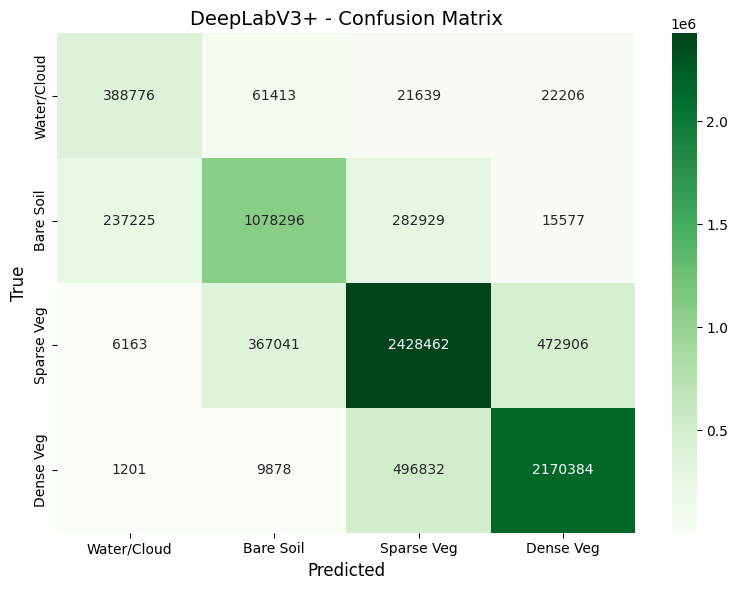

In [46]:
class_names = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
deep_cm = confusion_matrix(deep_all_labels, deep_all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(deep_cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('DeepLabV3+ - Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('deeplabv3_confusion_matrix.png', dpi=150)
plt.show()

Loss curves:

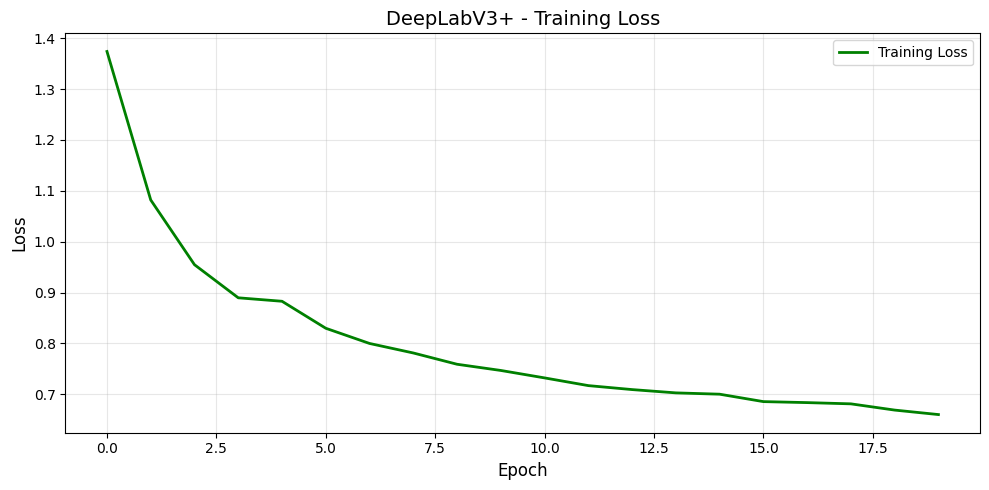

Final Training Loss: 0.6601

 DeepLabV3+ loss curve saved to: deeplabv3_loss_curves.png


In [47]:
plt.figure(figsize=(10, 5))
plt.plot(deep_train_losses, label='Training Loss', linewidth=2, color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('DeepLabV3+ - Training Loss', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('deeplabv3_loss_curves.png', dpi=150)
plt.show()

print(f"Final Training Loss: {deep_train_losses[-1]:.4f}")
print(f"\n DeepLabV3+ loss curve saved to: deeplabv3_loss_curves.png")

Visual prediction on one test image:

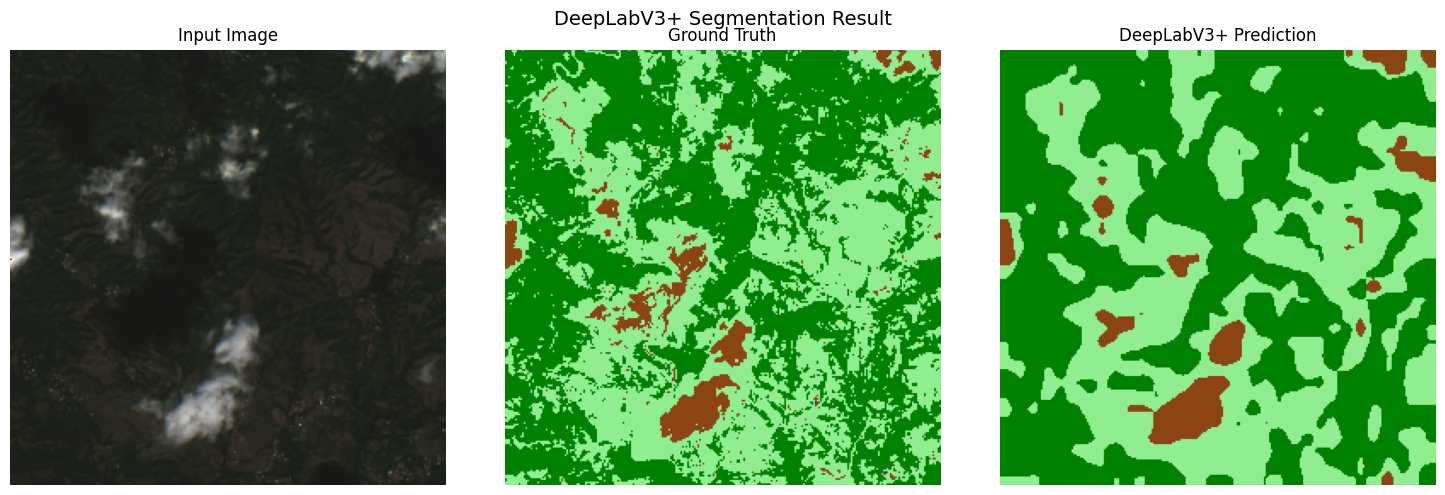

In [48]:
deep_model.eval()  
colours = {
    0: [0,   0,   255],  
    1: [139, 69,  19],   
    2: [144, 238, 144],  
    3: [0,   128, 0],     
}

with torch.no_grad():
    sample_img, sample_lbl = test_dataset[0]
    output = deep_model(sample_img.unsqueeze(0).to(device))
    pred_map = output['out'].argmax(dim=1).squeeze().cpu().numpy()

def to_colour_map(label_map):
    h, w = label_map.shape
    colour = np.zeros((h, w, 3), dtype=np.uint8)
    for class_id, rgb in colours.items():
        colour[label_map == class_id] = rgb
    return colour

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img.permute(1, 2, 0).numpy())
axes[0].set_title('Input Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(to_colour_map(sample_lbl.numpy()))
axes[1].set_title('Ground Truth', fontsize=12)
axes[1].axis('off')

axes[2].imshow(to_colour_map(pred_map))
axes[2].set_title('DeepLabV3+ Prediction', fontsize=12)
axes[2].axis('off')

plt.suptitle('DeepLabV3+ Segmentation Result', fontsize=14)
plt.tight_layout()
plt.savefig('deeplabv3_prediction.png', dpi=150)
plt.show()

# Comparison

In [49]:
from sklearn.metrics import f1_score

deeplab_f1 = f1_score(deep_all_labels, deep_all_preds, average=None)

svm_scores = {
    "Water/Cloud": 0.45,
    "Bare Soil": 0.61,
    "Sparse Veg": 0.76,
    "Dense Veg": 0.87,
    "Overall Acc": 0.75
}

cnn_scores = {
    "Water/Cloud": 0.53,   
    "Bare Soil": 0.75,  
    "Sparse Veg": 0.83,   
    "Dense Veg": 0.88,   
    "Overall Acc": 0.8174  
}

print("\n" + "="*65)
print("FULL MODEL COMPARISON (F1-score per class)")
print("="*65)
print(f"{'Class':<20} {'SVM':>10} {'Custom CNN':>12} {'DeepLabV3+':>12}")
print("-"*65)

classes = ['Water/Cloud', 'Bare Soil', 'Sparse Veg', 'Dense Veg']
for i, cls in enumerate(classes):
    print(f"{cls:<20} {svm_scores[cls]:>10.2f} {cnn_scores[cls]:>12.2f} {deeplab_f1[i]:>12.3f}")

print(f"{'Overall Acc':<20} {svm_scores['Overall Acc']:>10.2f} "f"{cnn_scores['Overall Acc']:>12.3f} {deep_accuracy:>12.3f}")
print("="*65)


FULL MODEL COMPARISON (F1-score per class)
Class                       SVM   Custom CNN   DeepLabV3+
-----------------------------------------------------------------
Water/Cloud                0.45         0.53        0.690
Bare Soil                  0.61         0.75        0.689
Sparse Veg                 0.76         0.83        0.747
Dense Veg                  0.87         0.88        0.810
Overall Acc                0.75        0.817        0.753


**ANALYSIS**:

**Original findings, 10 epochs on DeepLabV3+:**
The custom CNN, was the most accurate model, with an overall accuracy of 81%, outperforming both the SVM baseline (75%) and the pre-trained DeepLabv3+ (74%). The CNN's superior performance can be attributed to its patch-based approach (7×7 patches) which captures local spatial patterns effectively, and its training from scratch on 20 epochs specifically for this dataset. DeepLabV3+, while pre-trained on ImageNet, was limited to 10 epochs due to computational constraints and may benefit from additional fine-tuning. Notably, all models performed best on Dense Vegetation and struggled most with Water/Cloud classification, suggesting this class may benefit from additional training samples or spectral bands.

**Updated findings, 20 epochs on DeepLabV3+ (same number as CNN):**
Following the initial training, DeepLabV3+ was further trained with 20 epochs under the same conditions to ensure a fair comparison. Under extended training, performance improved slightly, to 75.8%, compared to the original 74%. However the custom CNN maintained its 81% accuracy, suggesting that the observed gap is not soley due to insufficient training of DeepLabV3+. To verify implementation stability, DeepLabV3+ was evaluated on both Apple Silicon (M4 MacBook Pro) and an NVIDIA GPU (5070 ti). Results were relatively consistent across hardware (0.754 vs 0.758), indicating negligible variance due to computational platform.